# **SmartCare_Readmission_Prediction**

# Connecting Colab to Drive

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importing the tools needed

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42

# ***Task 2 - Dataset Understanding***

# Loading data files

In [41]:
df = pd.read_csv('/content/drive/MyDrive/SmartCare/smartcare_ai_dataset_1000.csv')
data_dict = pd.read_csv('/content/drive/MyDrive/SmartCare/smartcare_ai_dataset_data_dictionary.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 33)


,record_id,patient_id,age,gender,blood_group,department,diagnosis,appointment_date,waiting_days,previous_appointments,missed_previous_appointments,appointment_status,admitted,room_type,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,payment_status,payment_method,no_show,readmitted_30_days,disease_risk_level
0,1,P10001,53,Male,A-,General Medicine,Migraine,2025-04-10,10,1,0,Completed,0,NaN,0,1,127,75,117,211,26.1,0,3,2000,0,0,11596,13596,Paid,Insurance,0,0,High
1,2,P10002,26,Male,B-,General Medicine,Diabetes,2025-05-15,2,3,1,Completed,0,NaN,0,0,130,73,136,173,32.8,0,1,2000,0,0,3652,5652,Paid,Insurance,0,0,Medium
2,3,P10003,22,Male,B+,Orthopedics,Back Pain,2025-07-09,22,7,1,No-Show,0,NaN,0,1,141,64,90,176,29.4,1,0,2500,0,1200,2562,6262,Unpaid,Insurance,1,0,Medium
3,4,P10004,44,Female,AB-,Cardiology,Asthma,2025-10-16,16,1,0,Completed,0,NaN,0,0,124,82,126,189,24.9,2,1,2000,0,5000,10262,17262,Paid,Online,0,0,Medium
4,5,P10005,51,Female,O+,Neurology,Hypertension,2025-12-18,12,4,0,Scheduled,0,NaN,0,1,119,81,65,195,27.0,2,0,4000,0,6000,10414,20414,Paid,Cash,0,0,Medium


# Looking at the data dictionary

In [42]:
pd.set_option('display.max_rows', None)
data_dict

,Column,Description
0,record_id,Unique row identifier
1,patient_id,Synthetic patient identifier
2,age,Patient age in years
3,gender,Patient gender
4,blood_group,Patient blood group
5,department,Hospital department
6,diagnosis,Primary diagnosis category
7,appointment_date,Appointment date
8,waiting_days,Number of days between booking and appointment
9,previous_appointments,Number of previous appointments


# Checking the structure of the data

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     1000 non-null   int64  
 1   patient_id                    1000 non-null   object 
 2   age                           1000 non-null   int64  
 3   gender                        1000 non-null   object 
 4   blood_group                   1000 non-null   object 
 5   department                    1000 non-null   object 
 6   diagnosis                     1000 non-null   object 
 7   appointment_date              1000 non-null   object 
 8   waiting_days                  1000 non-null   int64  
 9   previous_appointments         1000 non-null   int64  
 10  missed_previous_appointments  1000 non-null   int64  
 11  appointment_status            1000 non-null   object 
 12  admitted                      1000 non-null   int64  
 13  room

# Getting exact missing value counts

In [44]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report[missing_report['missing_count'] > 0]

,missing_count,missing_pct
room_type,906,90.6


# Checking for duplicate records

In [45]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated patient_id values:", df['patient_id'].duplicated().sum())
print("Duplicated record_id values:", df['record_id'].duplicated().sum())

Fully duplicated rows: 0
Duplicated patient_id values: 0
Duplicated record_id values: 0


# Understanding the target variable (readmitted_30_days)

In [46]:
print("Overall distribution of readmitted_30_days (all 1000 rows):")
print(df['readmitted_30_days'].value_counts())
print()
print("Distribution of admitted:")
print(df['admitted'].value_counts())
print()
print("readmitted_30_days broken down by admission status:")
print(df.groupby('admitted')['readmitted_30_days'].value_counts().unstack(fill_value=0))

Overall distribution of readmitted_30_days (all 1000 rows):
readmitted_30_days
0    747
1    253
Name: count, dtype: int64

Distribution of admitted:
admitted
0    670
1    330
Name: count, dtype: int64

readmitted_30_days broken down by admission status:
readmitted_30_days    0    1
admitted                    
0                   670    0
1                    77  253


# Creating the real dataset for modelling

In [47]:
df_model = df[df['admitted'] == 1].copy().reset_index(drop=True)

print("Modelling subset shape:", df_model.shape)
print()
print("Class balance:")
print(df_model['readmitted_30_days'].value_counts())
print(df_model['readmitted_30_days'].value_counts(normalize=True).round(3) * 100)

Modelling subset shape: (330, 33)

Class balance:
readmitted_30_days
1    253
0     77
Name: count, dtype: int64
readmitted_30_days
1    76.7
0    23.3
Name: proportion, dtype: float64


# ***Task 03 — Data Preprocessing and Feature Engineering***

# Removing columns that doesn't need

In [48]:
df_clean = df_model.drop(columns=['record_id', 'patient_id', 'no_show', 'disease_risk_level'])
print(df_clean.shape)
df_clean.columns.tolist()

(330, 29)


['age',
 'gender',
 'blood_group',
 'department',
 'diagnosis',
 'appointment_date',
 'waiting_days',
 'previous_appointments',
 'missed_previous_appointments',
 'appointment_status',
 'admitted',
 'room_type',
 'length_of_stay_days',
 'previous_admissions',
 'systolic_bp',
 'diastolic_bp',
 'blood_sugar_mg_dl',
 'cholesterol_mg_dl',
 'bmi',
 'lab_tests_count',
 'treatments_count',
 'consultation_fee_lkr',
 'room_charge_lkr',
 'lab_charge_lkr',
 'medicine_charge_lkr',
 'total_bill_lkr',
 'payment_status',
 'payment_method',
 'readmitted_30_days']

# Double-checking for missing values again

In [49]:
print("Missing values before fix:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Genuine missing data (236 of 330 admitted patients have no recorded room_type).
# We keep it as its own "Unknown" category instead of guessing a room type.
df_clean['room_type'] = df_clean['room_type'].fillna('Unknown')

print("\nAfter fix:")
print(df_clean['room_type'].value_counts())

Missing values before fix:
room_type    236
dtype: int64

After fix:
room_type
Unknown         236
General Ward     52
Private Room     33
ICU               9
Name: count, dtype: int64


# Checking for extreme/unusual values

In [50]:
numeric_cols = ['age', 'waiting_days', 'previous_appointments', 'missed_previous_appointments',
                'length_of_stay_days', 'previous_admissions', 'systolic_bp', 'diastolic_bp',
                'blood_sugar_mg_dl', 'cholesterol_mg_dl', 'bmi', 'lab_tests_count',
                'treatments_count', 'consultation_fee_lkr', 'room_charge_lkr', 'lab_charge_lkr',
                'medicine_charge_lkr', 'total_bill_lkr']

def iqr_outlier_report(data, cols):
    report = {}
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
        report[col] = n_outliers
    return pd.Series(report).sort_values(ascending=False)

outlier_counts = iqr_outlier_report(df_clean, numeric_cols)
outlier_counts[outlier_counts > 0]

,0
room_charge_lkr,44
total_bill_lkr,23
previous_admissions,21
lab_charge_lkr,16
lab_tests_count,9
treatments_count,8
missed_previous_appointments,6
bmi,5
systolic_bp,4
age,3


# Creating smarter features from the raw data

In [51]:
if 'appointment_date' in df_clean.columns:
    df_clean['appointment_date'] = pd.to_datetime(df_clean['appointment_date'])
    df_clean['appointment_month'] = df_clean['appointment_date'].dt.month
    df_clean = df_clean.drop(columns=['appointment_date'])
else:
    print("'appointment_date' column not found, assuming it was already processed.")

# 2. Missed appointment rate — what fraction of past appointments did they skip?
df_clean['missed_appointment_rate'] = (
    df_clean['missed_previous_appointments'] / df_clean['previous_appointments'].replace(0, np.nan)
).fillna(0)

# 3. Blood pressure category — turns raw numbers into a clinical label
def bp_category(row):
    if row['systolic_bp'] >= 140 or row['diastolic_bp'] >= 90:
        return 'High'
    elif row['systolic_bp'] >= 130 or row['diastolic_bp'] >= 80:
        return 'Elevated'
    else:
        return 'Normal'

df_clean['bp_category'] = df_clean.apply(bp_category, axis=1)

# 4. Average cost per day of stay
df_clean['cost_per_day'] = (
    df_clean['total_bill_lkr'] / df_clean['length_of_stay_days'].replace(0, np.nan)
).fillna(df_clean['total_bill_lkr'])

# 5. Combined prior healthcare usage
df_clean['prior_utilisation'] = df_clean['previous_admissions'] + df_clean['previous_appointments']

print("New features created!")
df_clean[['appointment_month', 'missed_appointment_rate', 'bp_category', 'cost_per_day', 'prior_utilisation']].head()

New features created!


,appointment_month,missed_appointment_rate,bp_category,cost_per_day,prior_utilisation
0,10,0.000000,Normal,11550.200000,1
1,10,0.500000,Elevated,41744.000000,3
2,11,0.428571,Elevated,7017.333333,8
3,10,0.000000,Elevated,7380.666667,1
4,7,0.000000,Elevated,11818.666667,1


# Turning text categories into numbers (encoding)

In [52]:
categorical_cols = ['gender', 'blood_group', 'department', 'diagnosis', 'room_type',
                    'appointment_status', 'payment_status', 'payment_method', 'bp_category']

df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (330, 60)


,age,waiting_days,previous_appointments,missed_previous_appointments,admitted,length_of_stay_days,previous_admissions,systolic_bp,diastolic_bp,blood_sugar_mg_dl,cholesterol_mg_dl,bmi,lab_tests_count,treatments_count,consultation_fee_lkr,room_charge_lkr,lab_charge_lkr,medicine_charge_lkr,total_bill_lkr,readmitted_30_days,appointment_month,missed_appointment_rate,cost_per_day,prior_utilisation,gender_Male,blood_group_A-,blood_group_AB+,blood_group_AB-,blood_group_B+,blood_group_B-,blood_group_O+,blood_group_O-,department_General Medicine,department_Laboratory Services,department_Neurology,department_Orthopedics,department_Pediatrics,department_Radiology,diagnosis_Back Pain,diagnosis_Chest Pain,diagnosis_Diabetes,diagnosis_Fever,diagnosis_Fracture,diagnosis_Hypertension,diagnosis_Kidney Infection,diagnosis_Migraine,diagnosis_Pneumonia,room_type_ICU,room_type_Private Room,room_type_Unknown,appointment_status_Completed,appointment_status_No-Show,appointment_status_Scheduled,payment_status_Partially Paid,payment_status_Unpaid,payment_method_Cash,payment_method_Insurance,payment_method_Online,bp_category_High,bp_category_Normal
0,50,43,1,0,1,5,0,117,76,130,193,29.1,0,2,2500,45000,0,10251,57751,1,10,0.000000,11550.200000,1,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True
1,38,39,2,1,1,1,1,134,64,97,192,26.1,0,2,2000,25000,0,14744,41744,0,10,0.500000,41744.000000,3,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False
2,90,42,7,3,1,3,1,118,88,96,192,24.5,4,2,3500,10500,4800,2252,21052,1,11,0.428571,7017.333333,8,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
3,53,31,1,0,1,3,0,130,81,93,204,27.7,6,5,2500,0,7200,12442,22142,1,10,0.000000,7380.666667,1,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False
4,32,5,1,0,1,3,0,126,80,98,217,20.7,5,2,2000,0,15000,18456,35456,1,7,0.000000,11818.666667,1,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False


# Splitting the data into "training" and "testing" sets

In [53]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['readmitted_30_days'])
y = df_encoded['readmitted_30_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))

Train shape: (264, 59)  Test shape: (66, 59)
Train class balance:
 readmitted_30_days
1    0.765
0    0.235
Name: proportion, dtype: float64
Test class balance:
 readmitted_30_days
1    0.773
0    0.227
Name: proportion, dtype: float64


# Scaling the numeric columns

In [54]:
from sklearn.preprocessing import StandardScaler

numeric_features = numeric_cols + ['appointment_month', 'missed_appointment_rate',
                                    'cost_per_day', 'prior_utilisation']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Scaling complete.")
X_train_scaled[numeric_features].describe().T[['mean', 'std']]

Scaling complete.


,mean,std
age,-3.027881e-17,1.001899
waiting_days,8.410780e-17,1.001899
previous_appointments,4.037175e-17,1.001899
missed_previous_appointments,9.756505e-17,1.001899
length_of_stay_days,-1.076580e-16,1.001899
previous_admissions,-8.747212e-17,1.001899
systolic_bp,2.186803e-16,1.001899
diastolic_bp,-2.624164e-16,1.001899
blood_sugar_mg_dl,9.756505e-17,1.001899
cholesterol_mg_dl,-3.700743e-16,1.001899


# ***Task 04 — Exploratory Data Analysis (EDA)***

# Class distribution chart

/tmp/ipykernel_1236/669120840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


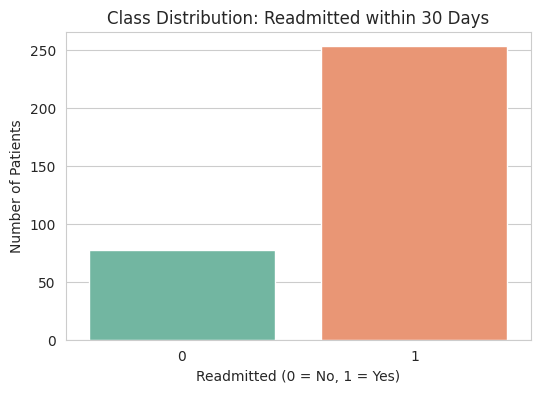

In [55]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title('Class Distribution: Readmitted within 30 Days')
plt.xlabel('Readmitted (0 = No, 1 = Yes)')
plt.ylabel('Number of Patients')
plt.show()

# Histograms of key numeric variables

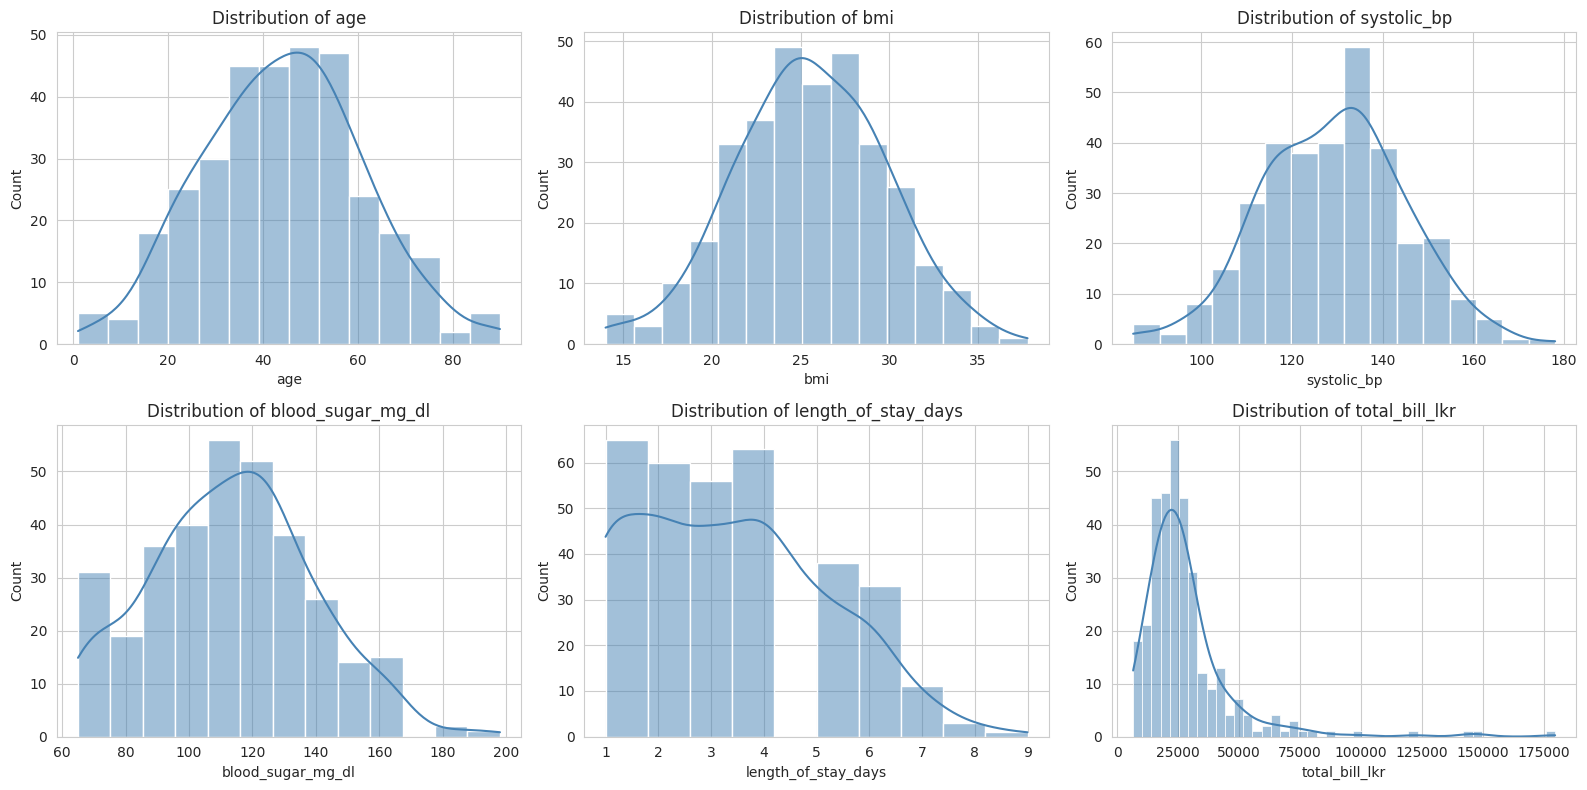

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
hist_cols = ['age', 'bmi', 'systolic_bp', 'blood_sugar_mg_dl', 'length_of_stay_days', 'total_bill_lkr']

for ax, col in zip(axes.flatten(), hist_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Boxplots — comparing readmitted vs. not-readmitted patients

/tmp/ipykernel_1236/2344566507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clean['readmitted_30_days'], y=df_clean[col], ax=ax, palette='Set2')
/tmp/ipykernel_1236/2344566507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clean['readmitted_30_days'], y=df_clean[col], ax=ax, palette='Set2')
/tmp/ipykernel_1236/2344566507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_clean['readmitted_30_days'], y=df_clean[col], ax=ax, palette='Set2')
/tmp/ipykernel_1236/2344566507.py:5: FutureWarning: 

Passing `palette` with

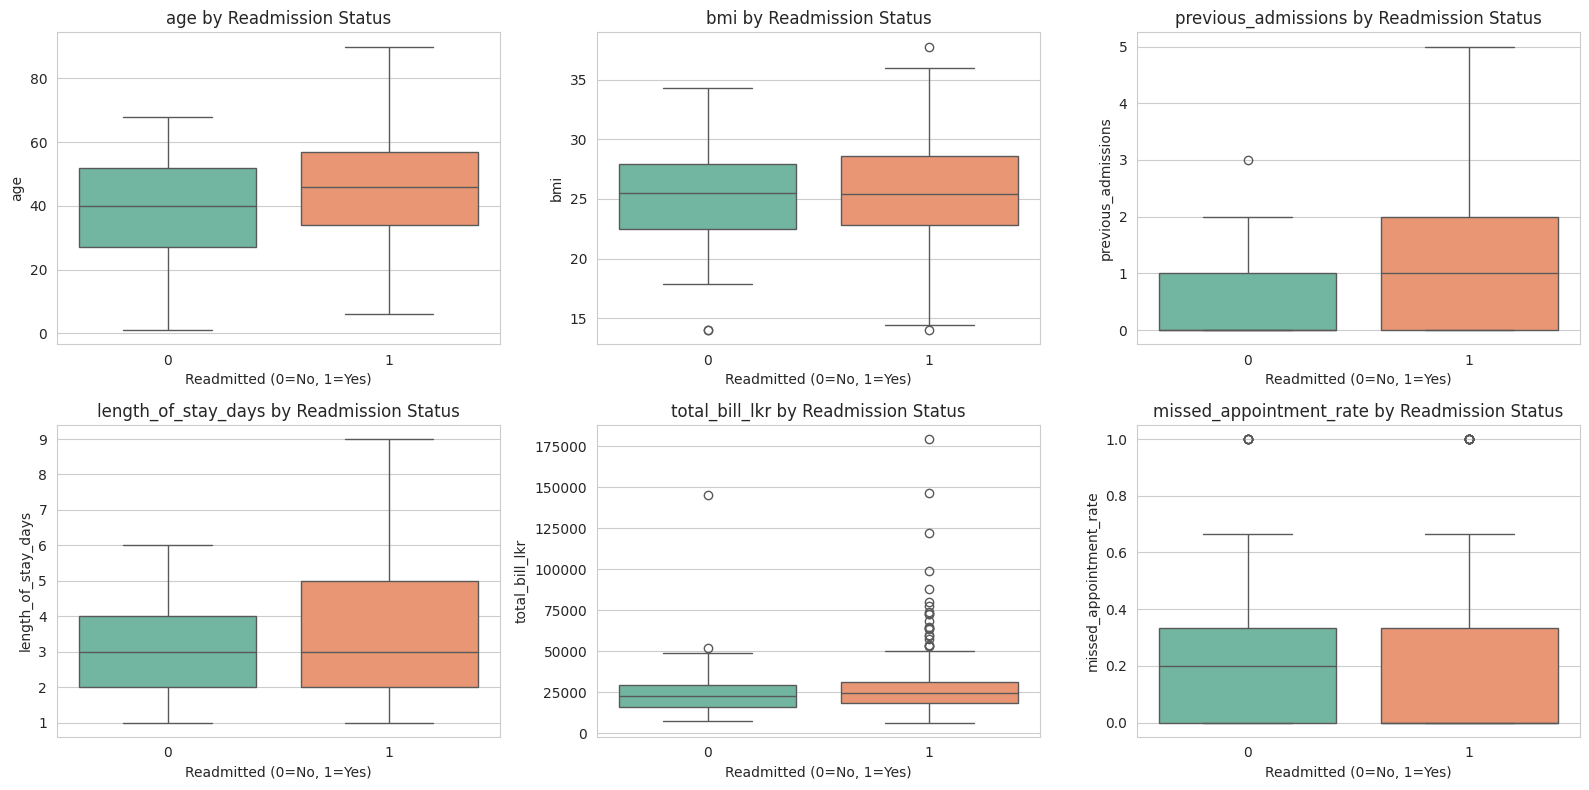

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
box_cols = ['age', 'bmi', 'previous_admissions', 'length_of_stay_days', 'total_bill_lkr', 'missed_appointment_rate']

for ax, col in zip(axes.flatten(), box_cols):
    sns.boxplot(x=df_clean['readmitted_30_days'], y=df_clean[col], ax=ax, palette='Set2')
    ax.set_title(f'{col} by Readmission Status')
    ax.set_xlabel('Readmitted (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

# Scatterplot — relationship between two numeric variables

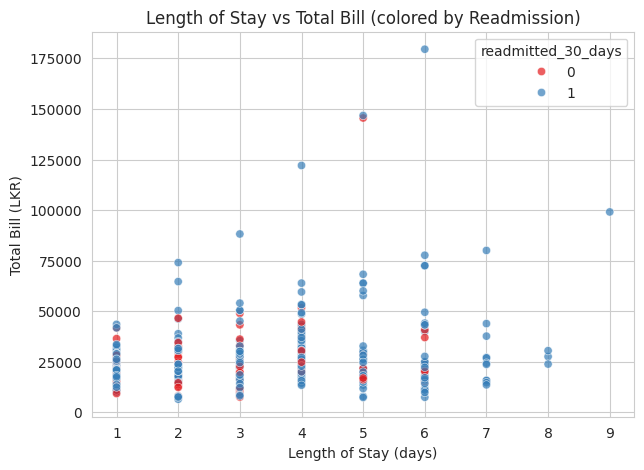

In [58]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_clean, x='length_of_stay_days', y='total_bill_lkr',
                 hue='readmitted_30_days', palette='Set1', alpha=0.7)
plt.title('Length of Stay vs Total Bill (colored by Readmission)')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Total Bill (LKR)')
plt.show()

# Correlation heatmap

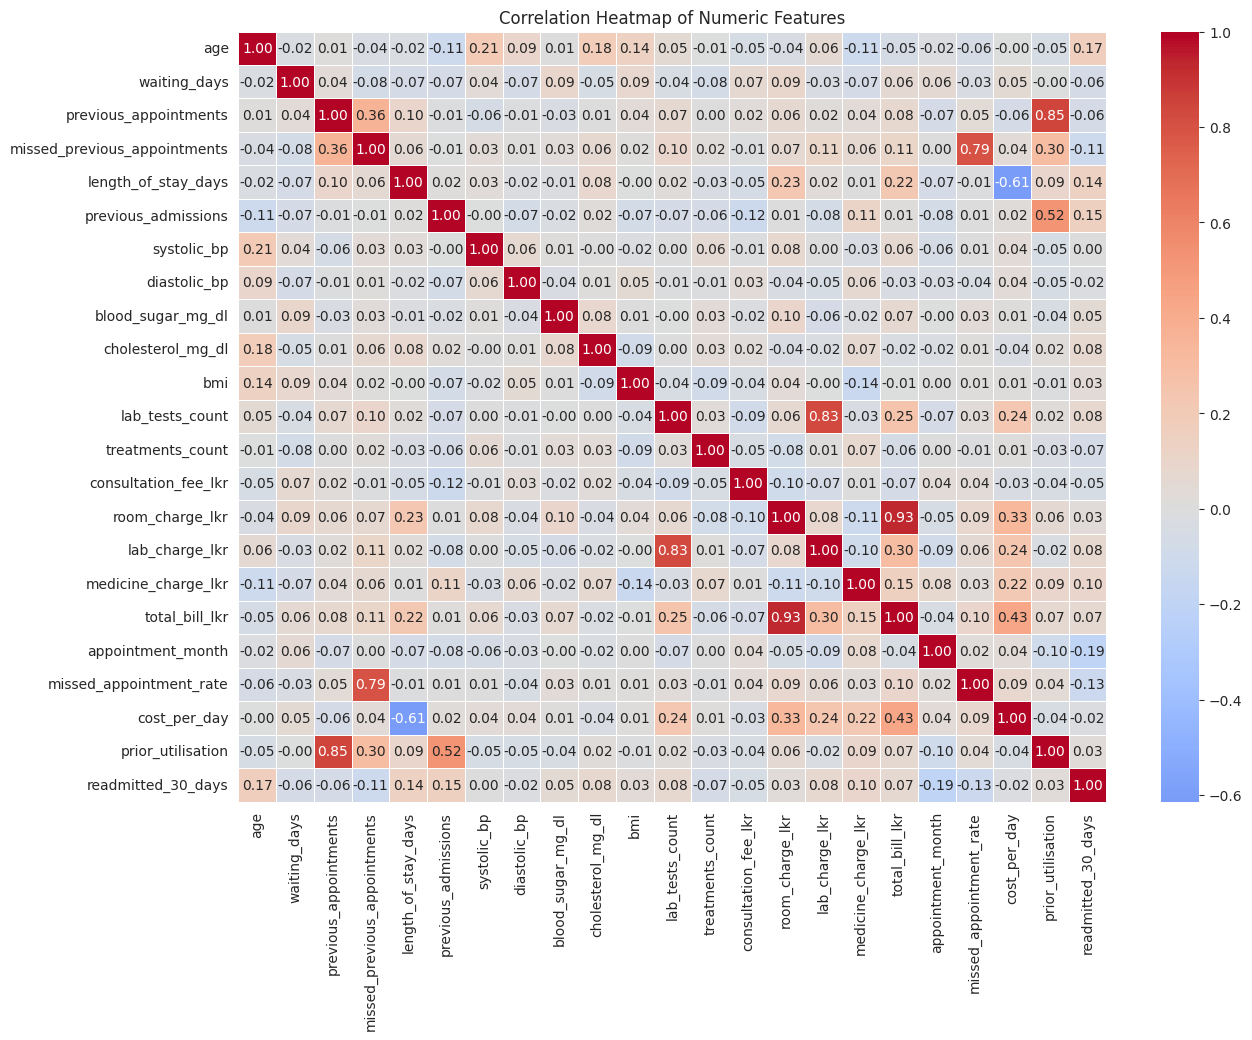

In [59]:
plt.figure(figsize=(14, 10))
corr_cols = numeric_features + ['readmitted_30_days']
corr_matrix = df_clean[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# EDA Insights

- The dataset is imbalanced: ~77% of admitted patients were readmitted within 30 days,
  only ~23% were not.
- No single feature strongly predicts readmission alone — the strongest correlations
  (appointment_month: -0.19, age: 0.17, previous_admissions: 0.15, length_of_stay_days: 0.14)
  are all fairly weak. This suggests readmission is driven by a combination of factors,
  motivating the use of machine learning models over simple rule-based logic.
- Patients with more previous_admissions and older patients show a slight tendency
  toward higher readmission risk.
- Engineered features (prior_utilisation, missed_appointment_rate) are highly correlated
  with the raw columns they were derived from, as expected.
- Room charge and total bill are strongly correlated (0.93), as expected since room
  charges are a major component of the total bill.

# ***Task 05 – Machine Learning Model Development***

# Training Model 1 — Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Logistic Regression - simple, interpretable baseline model
log_reg_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
log_reg_grid = GridSearchCV(log_reg, log_reg_params, cv=5, scoring='roc_auc', n_jobs=-1)
log_reg_grid.fit(X_train_scaled, y_train)

print("Best parameters:", log_reg_grid.best_params_)
print("Best cross-validation ROC-AUC:", round(log_reg_grid.best_score_, 4))

best_log_reg = log_reg_grid.best_estimator_

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation ROC-AUC: 0.6866


# Training Model 2 — Random Forest

In [61]:
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best cross-validation ROC-AUC:", round(rf_grid.best_score_, 4))

best_rf = rf_grid.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation ROC-AUC: 0.645


# Training Model 3 — XGBoost

In [62]:
from xgboost import XGBClassifier

# Compute scale_pos_weight for class imbalance (XGBoost's equivalent of class_weight)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

xgb = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                     eval_metric='logloss')
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='roc_auc', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best cross-validation ROC-AUC:", round(xgb_grid.best_score_, 4))

best_xgb = xgb_grid.best_estimator_

Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best cross-validation ROC-AUC: 0.6275


# Evaluating all three models on the test set

In [63]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                               f1_score, roc_auc_score, confusion_matrix, classification_report)

models = {
    'Logistic Regression': best_log_reg,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).round(4)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5909,0.8158,0.6078,0.6966,0.6196
1,Random Forest,0.7727,0.7727,1.0000,0.8718,0.5765
2,XGBoost,0.6970,0.8780,0.7059,0.7826,0.6327


# Confusion matrices

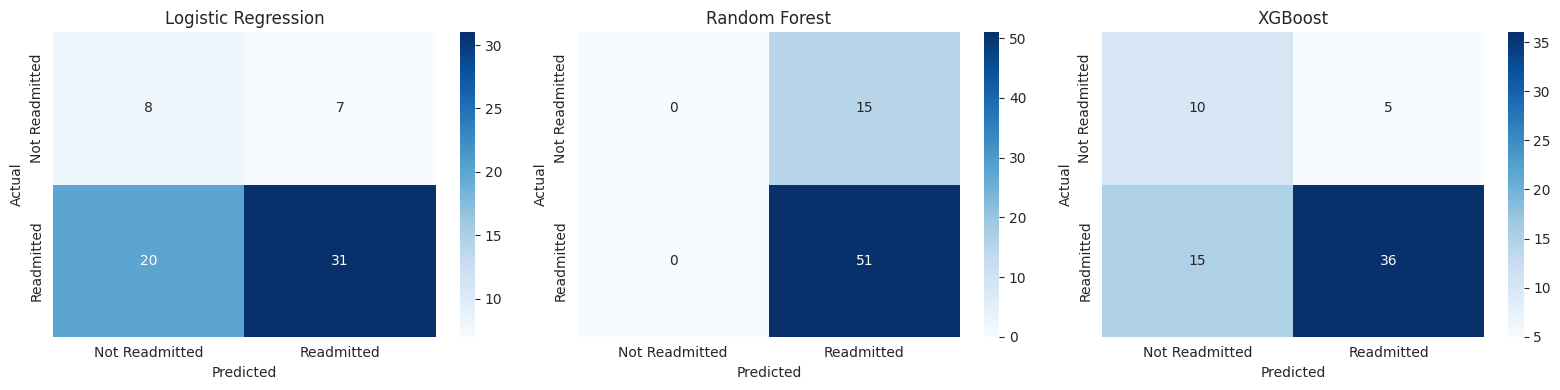

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Detailed classification report

In [65]:
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted']))
    print()

--- Logistic Regression ---
                precision    recall  f1-score   support

Not Readmitted       0.29      0.53      0.37        15
    Readmitted       0.82      0.61      0.70        51

      accuracy                           0.59        66
     macro avg       0.55      0.57      0.53        66
  weighted avg       0.70      0.59      0.62        66


--- Random Forest ---
                precision    recall  f1-score   support

Not Readmitted       0.00      0.00      0.00        15
    Readmitted       0.77      1.00      0.87        51

      accuracy                           0.77        66
     macro avg       0.39      0.50      0.44        66
  weighted avg       0.60      0.77      0.67        66


--- XGBoost ---
                precision    recall  f1-score   support

Not Readmitted       0.40      0.67      0.50        15
    Readmitted       0.88      0.71      0.78        51

      accuracy                           0.70        66
     macro avg       0.64   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Model Comparison and Best Model Justification

- Three models were trained and evaluated: Logistic Regression, Random Forest, and XGBoost.

- While Random Forest achieved the highest raw accuracy (0.77) and a perfect recall (1.00),
inspection of its confusion matrix reveals it predicted "Readmitted" for nearly all test
patients, correctly identifying 0 of 15 "Not Readmitted" cases. This makes it clinically
unusable despite its high accuracy — a known risk when accuracy is used as the sole metric
on an imbalanced dataset.

- XGBoost achieved the highest ROC-AUC (0.6327) and was the only model to meaningfully
distinguish both classes, correctly identifying 36/51 readmitted patients and 10/15
non-readmitted patients. Logistic Regression performed close behind (ROC-AUC 0.6196)
with slightly better recall but more false positives on the minority class.

- **Selected best model: XGBoost**, based on ROC-AUC as the primary metric (most reliable
under class imbalance) and its more balanced confusion matrix, despite Random Forest's
higher headline accuracy.

# ***Task 07 — Explainable AI Analysis***

# Getting feature importance scores

In [66]:
importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

importance_df.head(15)

,Feature,Importance
0,appointment_month,0.069737
1,previous_admissions,0.067996
2,missed_appointment_rate,0.054709
3,bp_category_Normal,0.052175
4,blood_group_A-,0.051182
5,cholesterol_mg_dl,0.049114
6,bmi,0.044267
7,blood_group_O-,0.042070
8,lab_tests_count,0.040227
9,diastolic_bp,0.038280


# Plotting the top 15 features

/tmp/ipykernel_1236/3768462953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y='Feature', x='Importance', palette='viridis')


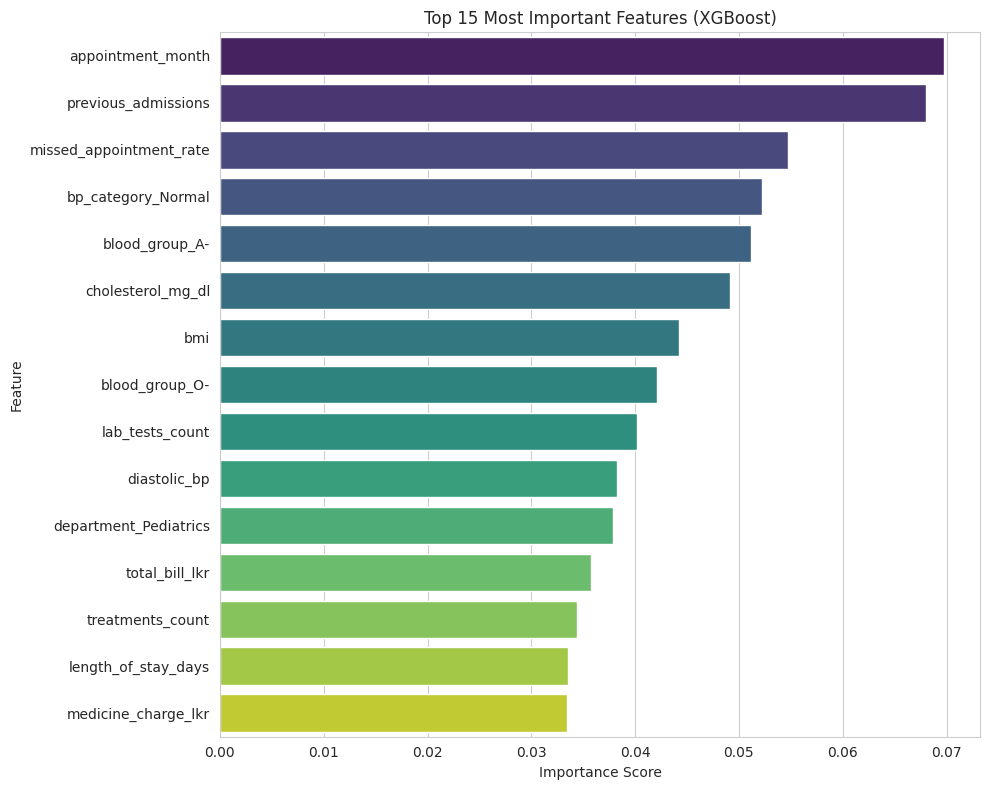

In [67]:
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
sns.barplot(data=top_features, y='Feature', x='Importance', palette='viridis')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Installing and importing SHAP

In [68]:
!pip install shap -q
import shap

# Creating the SHAP explainer

In [69]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values calculated for", X_test_scaled.shape[0], "test patients")

SHAP values calculated for 66 test patients


# Overall summary plot

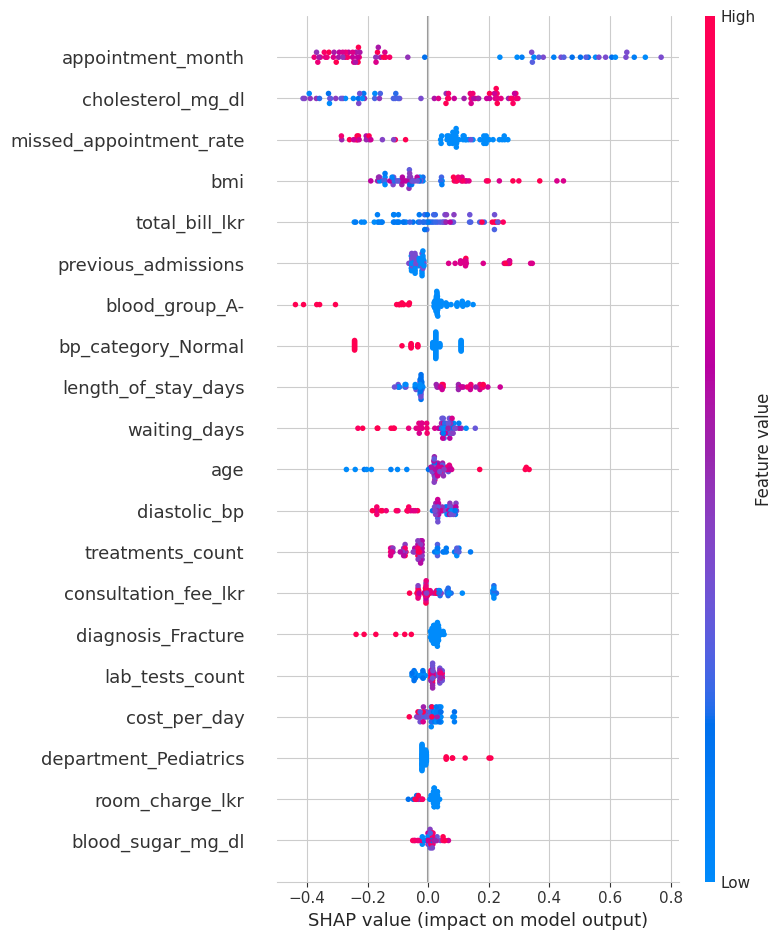

In [70]:
shap.summary_plot(shap_values, X_test_scaled, show=True)

# Explaining one individual patient's prediction

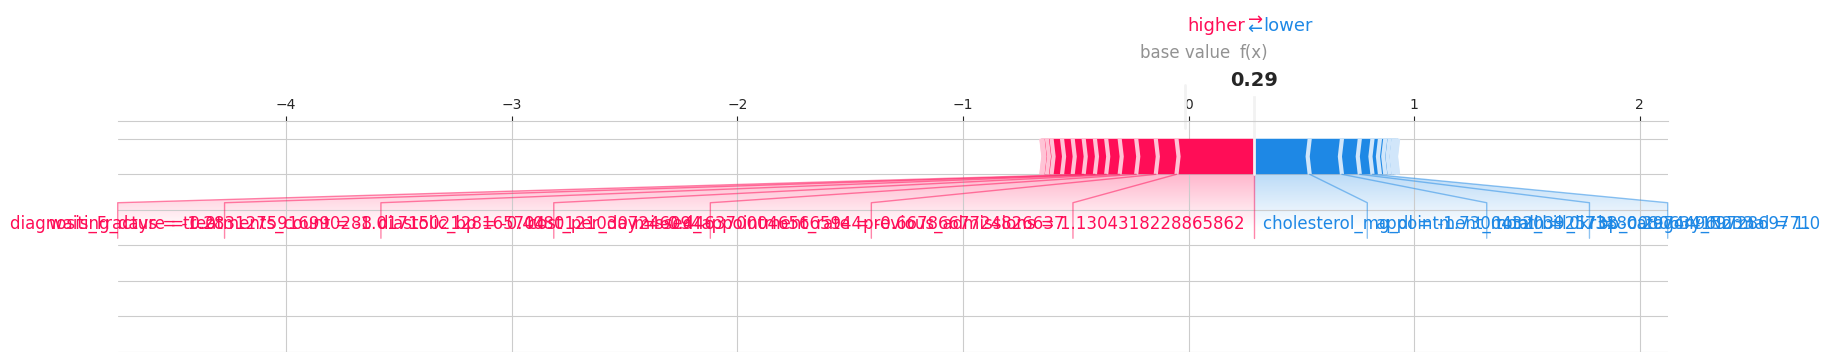

Actual outcome for this patient: 1
Model's predicted probability: 0.5720683


In [71]:
patient_index = 0

shap.force_plot(explainer.expected_value, shap_values[patient_index],
                 X_test_scaled.iloc[patient_index], matplotlib=True, show=True)

print("Actual outcome for this patient:", y_test.iloc[patient_index])
print("Model's predicted probability:", best_xgb.predict_proba(X_test_scaled)[patient_index][1])

In [72]:
import numpy as np

mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Mean |SHAP value|': mean_abs_shap
}).sort_values('Mean |SHAP value|', ascending=False).reset_index(drop=True)

shap_importance.head(15)

,Feature,Mean |SHAP value|
0,appointment_month,0.340983
1,cholesterol_mg_dl,0.209007
2,missed_appointment_rate,0.152062
3,bmi,0.117136
4,total_bill_lkr,0.103170
5,previous_admissions,0.087585
6,blood_group_A-,0.081149
7,bp_category_Normal,0.075683
8,length_of_stay_days,0.072457
9,waiting_days,0.070093


In [73]:
patient_index = 0
patient_shap = pd.DataFrame({
    'Feature': X_test_scaled.columns,
    'Value': X_test_scaled.iloc[patient_index].values,
    'SHAP contribution': shap_values[patient_index]
}).sort_values('SHAP contribution', key=abs, ascending=False).reset_index(drop=True)

print("Base value (average prediction):", explainer.expected_value)
print("This patient's final prediction (probability):", best_xgb.predict_proba(X_test_scaled)[patient_index][1])
print("Actual outcome:", y_test.iloc[patient_index])
print()
patient_shap.head(10)

Base value (average prediction): -0.013814751
This patient's final prediction (probability): 0.5720683
Actual outcome: 1



,Feature,Value,SHAP contribution
0,previous_admissions,1.130432,0.343714
1,cholesterol_mg_dl,-1.730043,-0.246723
2,appointment_month,0.731801,-0.142871
3,missed_appointment_rate,-0.667867,0.091709
4,cost_per_day,-0.44637,0.086812
5,total_bill_lkr,-0.29745,-0.079164
6,diastolic_bp,-0.408012,0.073298
7,treatments_count,-1.01715,0.059757
8,bp_category_Normal,True,-0.056174
9,waiting_days,-1.283128,0.049927


# Feature Importance & SHAP

Two complementary explainability techniques were applied to the best-performing model
(XGBoost): built-in feature importance and SHAP (SHapley Additive exPlanations).

**Global feature importance:**
Both methods largely agree on the most influential features, which strengthens confidence
that these findings are genuine rather than artifacts of a single technique:
- appointment_month was the top-ranked feature under both methods, suggesting readmission
  risk fluctuates seasonally — possibly linked to seasonal illness patterns.
- previous_admissions was highly influential under both methods, aligning with clinical
  intuition: patients with a history of frequent hospital admissions are more likely to
  be readmitted again.
- missed_appointment_rate also ranked highly in both, reflecting a relationship between
  patient engagement with follow-up care and readmission outcomes.
- Clinical vitals (cholesterol, BMI, blood pressure) contributed meaningfully in both
  analyses, despite showing only weak individual correlations during EDA — demonstrating
  that machine learning models can capture combined, non-linear interactions between
  features that simple correlation analysis alone would miss.

**Individual-level explanation (SHAP):**
Unlike feature importance, which only shows overall patterns, SHAP explains individual
predictions. For one test patient (actual outcome: readmitted), the model predicted a
57.2% readmission probability. SHAP revealed that this patient's high number of previous
admissions was the dominant factor pushing the prediction toward "readmitted" (+0.34),
partially offset by a below-average cholesterol reading (-0.25) and a favorable
appointment month (-0.14). This patient-level transparency is clinically valuable —
rather than receiving a single opaque risk score, clinicians can see exactly which
factors drove an individual patient's prediction, supporting more informed and
trustworthy decision-making.

**Transparency and ethical considerations:**
Some influential features (e.g. blood_group) lack an obvious direct clinical mechanism
linking them to readmission risk. Given the modest dataset size (330 patients), such
patterns could reflect coincidental correlations specific to this dataset rather than
genuine causal relationships, and should not be used to justify differential treatment
of patients without further clinical validation. More broadly, this highlights the
importance of pairing model-driven insights with domain expertise before they inform
real clinical decisions. SHAP's individual-level transparency also supports
accountability: if a patient is flagged as high-risk, clinicians can verify whether the
model's reasoning aligns with clinical judgment before acting on it, rather than
trusting an unexplainable "black box" prediction. Models should also be periodically
re-evaluated as more data becomes available, to confirm whether identified patterns
hold up over time or were artifacts of this particular dataset.

# Saving trained model, scaler, and feature list

In [74]:
import joblib

joblib.dump(best_xgb, 'readmission_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train_scaled.columns), 'feature_columns.pkl')
joblib.dump(numeric_features, 'numeric_features.pkl')

print("Saved: readmission_model.pkl, scaler.pkl, feature_columns.pkl, numeric_features.pkl")

Saved: readmission_model.pkl, scaler.pkl, feature_columns.pkl, numeric_features.pkl


# Copying files to permanent Drive folder

In [75]:
import shutil

shutil.copy('readmission_model.pkl', '/content/drive/MyDrive/SmartCare/readmission_model.pkl')
shutil.copy('scaler.pkl', '/content/drive/MyDrive/SmartCare/scaler.pkl')
shutil.copy('feature_columns.pkl', '/content/drive/MyDrive/SmartCare/feature_columns.pkl')
shutil.copy('numeric_features.pkl', '/content/drive/MyDrive/SmartCare/numeric_features.pkl')

print("Copied to Drive.")

Copied to Drive.
